# Ridge regression to avoid overfitting

In this notebook, we will reuse the polynomial regression notebook to see how ridge regularization fixes the problem. In particular, we will:

- Introduce ridge regression
- Compare underfitting vs overfitting vs regularization
- Observe the effect of the regularization parameter λ

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

## Generate synthetic data

In [3]:
np.random.seed(0)

N = 10  # small dataset to emphasize overfitting
# Input feature
X = np.linspace(0,2,N).reshape(-1, 1)
# Ground-truth target
y_true = np.sin(2 * np.pi * X[:, 0])
# Noisy observations
y = y_true + 0.25 * np.random.randn(N)

# Test data (dense grid)
X_test = np.linspace(0, 2, 200).reshape(-1, 1)
# Ground-truth target
y_test_true = np.sin(2 * np.pi * X_test[:, 0])

## Build polynomial features

In [4]:
# Using scikit-learn
degree = 12  # high degree to induce overfitting
poly = PolynomialFeatures(degree=degree, include_bias=False)

X_poly = poly.fit_transform(X)
X_test_poly = poly.transform(X_test)

## Data normalization

Feature scaling is particularly important for ridge regression. Without notmalization, regularization would be inconsistent across variables.

In [5]:
scaler = StandardScaler()

X_poly_scaled = scaler.fit_transform(X_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

## Train models (least squares)

In [6]:
# Ordinary least squares (overfitting)
ols = LinearRegression()
ols.fit(X_poly_scaled, y)

# Ridge with different lambda values (for comparison)
ridge_small = Ridge(alpha=1e-4)
ridge_medium = Ridge(alpha=1)
ridge_large = Ridge(alpha=100)

ridge_small.fit(X_poly_scaled, y)
ridge_medium.fit(X_poly_scaled, y)
ridge_large.fit(X_poly_scaled, y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


## Predictions

In [7]:
y_ols = ols.predict(X_test_poly_scaled)

y_ridge_small = ridge_small.predict(X_test_poly_scaled)
y_ridge_medium = ridge_medium.predict(X_test_poly_scaled)
y_ridge_large = ridge_large.predict(X_test_poly_scaled)

## Comparison plot

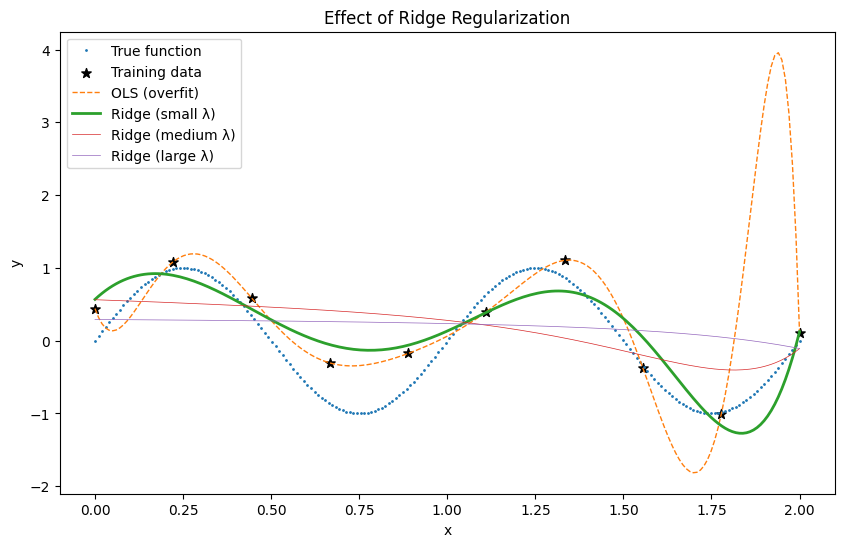

In [30]:
plt.figure(figsize=(10, 6))

# True function
plt.plot(X_test, y_test_true, '.', label="True function", ms=2)

# Training data
plt.scatter(X, y, marker='*', s=50, color='k', label="Training data")

# Models
plt.plot(X_test, y_ols, '--', linewidth=1, label="OLS (overfit)")
plt.plot(X_test, y_ridge_small, linewidth=2, label="Ridge (small λ)")
plt.plot(X_test, y_ridge_medium, linewidth=0.5, label="Ridge (medium λ)")
plt.plot(X_test, y_ridge_large, linewidth=0.5, label="Ridge (large λ)")

plt.legend()
plt.title("Effect of Ridge Regularization")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Error analysis

In [13]:
models = {
    "OLS": y_ols,
    "Ridge small λ": y_ridge_small,
    "Ridge medium λ": y_ridge_medium,
    "Ridge large λ": y_ridge_large
}

print("Test MSE:\n")

for name, y_pred in models.items():
    mse = mean_squared_error(y_test_true, y_pred)
    print(f"{name}: {mse:.2f}")

Test MSE:

OLS: 1.07
Ridge small λ: 0.17
Ridge medium λ: 0.45
Ridge large λ: 0.49


## Effect on parameters

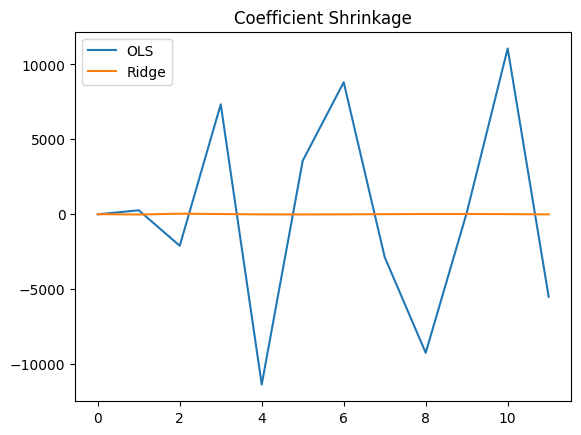

In [16]:
plt.plot(ols.coef_.ravel(), label="OLS")
plt.plot(ridge_small.coef_.ravel(), label="Ridge")
plt.legend()
plt.title("Coefficient Shrinkage")
plt.show()

## Results interpretation:

- The OLS model (no regularization) fits the training data almost perfectly but shows strong oscillations (overfitting)
- Ridge regression progressively smooths the solution by shrinking coefficients
- This biases the approximation, but improves generalization
- The regularization parameter λ controls the bias-variance trade-off
- Large λ results in underfitting